In [1]:
import torch
from models import Model
from utils import generate, f, thermal_analysis, thermal_analysis_dist, get_energies, get_magnetizations

import matplotlib.pyplot as plt
from functools import partial

In [2]:
# simulation parameters
J = 1
image_size = 32
channels = 1

hidden_dim = 10
save_path = "saved_models"

In [3]:
model = Model(in_channels=channels, hidden_dim=hidden_dim)
model.load_state_dict(torch.load(f"{save_path}/model_C1_J{J}_H{hidden_dim}.pth")["model_state_dict"])

<All keys matched successfully>

In [4]:
T, es, mag = thermal_analysis(partial(f, J=J), J, res=32, n=300, p=(0.5, 0.1), in_channels=channels)
T_, es_, mag_ = thermal_analysis(model,        J, res=32, n=300, p=(0.5, 0.1), in_channels=channels)

100%|██████████| 10/10 [02:04<00:00, 12.46s/it]


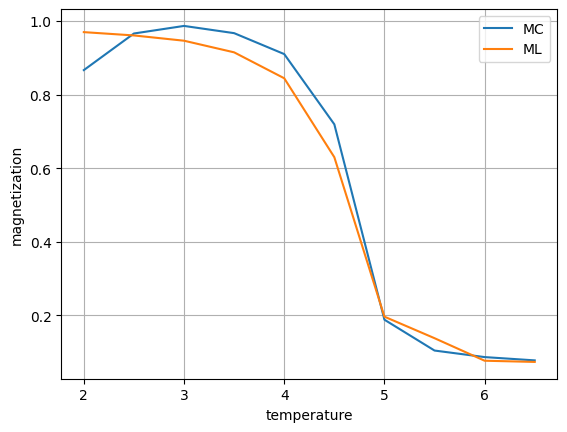

In [5]:
plt.plot(T, mag, label="MC")
plt.plot(T_, mag_, label="ML")
# plt.axhline(1, color="k")
# plt.axhline(0, color="k")

plt.xlabel("temperature")
plt.ylabel("magnetization")

plt.grid()
plt.legend()

In [6]:
# T, es_dist, mag_dist = thermal_analysis_dist(partial(f, J=J), J, res=32, n=200, p=(0.5, 0.1), in_channels=channels)
# T_, es_dist_, mag_dist_ = thermal_analysis_dist(model,        J, res=32, n=200, p=(0.5, 0.1), in_channels=channels)

  4%|▍         | 2/50 [00:10<04:07,  5.17s/it]


KeyboardInterrupt: 

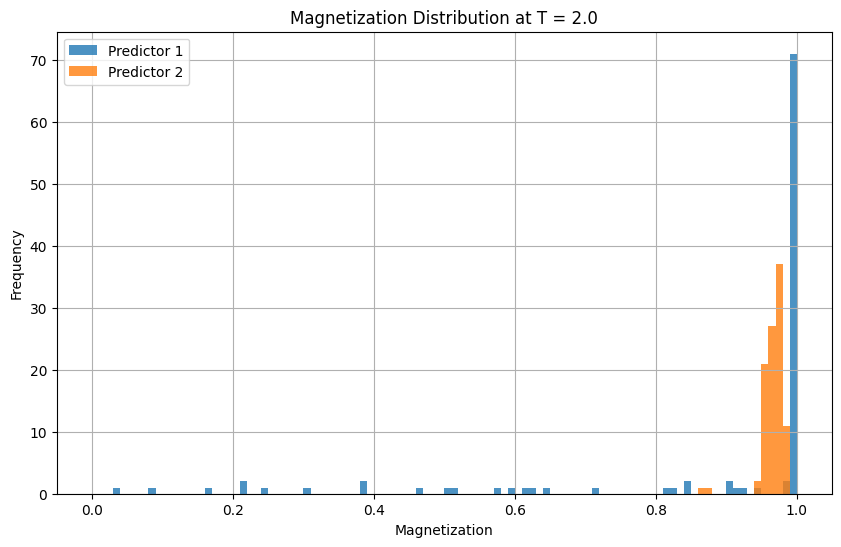

In [27]:
def compare_magnetization_distributions(predictors, temperature, J, res=32, n=100, p=(1.0, 0.1), in_channels=1):
    plt.figure(figsize=(10, 6))
    
    for i, predictor in enumerate(predictors):
        T = torch.ones(n) * temperature
        lattices = generate(predictor, res, T, n, p, in_channels)
        magnetizations = get_magnetizations(lattices)
        abs_magnetizations = torch.abs(magnetizations).numpy()
        
        plt.hist(abs_magnetizations, bins=100, alpha=0.8, label=f'Predictor {i+1}', range=(0, 1))
    
    plt.xlabel('Magnetization')
    plt.ylabel('Frequency')
    plt.title(f'Magnetization Distribution at T = {temperature}')
    plt.legend()
    plt.grid(True)
compare_magnetization_distributions(
    predictors=[
        partial(f, J=J),
        model
    ],
    temperature=2.0,
    J=J,
)

In [ ]:
# T = torch.tensor([7.0]*2)
# img = generate(partial(f, J=J), 128, T, n=1000, p=(1.0, 0.01), in_channels=channels)
# plt.imshow(img[0, 0])

In [ ]:
# T = torch.tensor([7.0]*2)
# img = generate(model, 128, T, n=1000, p=(1.0, 0.01), in_channels=channels)
# plt.imshow(img[0, 0])